# Tokenization evidence

In [1]:
# Move to the project root and load notebook dependencies.
%cd /workspaces/tesis_v4

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from torchvision import transforms

ROOT = Path.cwd()
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.style.use('default')
print(f'Root: {ROOT} | Device: {DEVICE}')

/workspaces/tesis_v4
Root: /workspaces/tesis_v4 | Device: cuda


## Load two road scenes and three beta checkpoints

In [2]:
CHECKPOINTS = {
    'β=0.0': ROOT / 'runs/component_refinement/01_corrected_reward_anchor/beta0.0_seed42/checkpoint_best.pt',
    'β=0.01': ROOT / 'runs/component_refinement/01_corrected_reward_anchor/beta0.01_seed42/checkpoint_best.pt',
    'β=0.1': ROOT / 'runs/component_refinement/01_corrected_reward_anchor/beta0.1_seed42/checkpoint_best.pt',
}
ROLLOUT_DIR = ROOT / 'data/rollouts/rwm_deterministic/scenario_0'
FRAME_A, FRAME_B = 60, 100  # Change deliberately to compare road scenes.

In [ ]:
# Choose two frames from one training rollout.
from rwm.commands.rwm_manual_test import load_model

for label, checkpoint in CHECKPOINTS.items():
    assert checkpoint.exists(), f'Missing {label} checkpoint: {checkpoint}'
ROLLOUT_PATH = sorted(ROLLOUT_DIR.rglob('*.npz'))[0]
with np.load(ROLLOUT_PATH) as rollout:
    raw_frames = rollout['obs']
assert max(FRAME_A, FRAME_B) < len(raw_frames), f'Frames must be below {len(raw_frames)}'

resize_to_model = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((64, 64), antialias=True),
])
def to_model_frame(index):
    return resize_to_model(Image.fromarray(raw_frames[index])).unsqueeze(0).to(DEVICE)

image_a, image_b = to_model_frame(FRAME_A), to_model_frame(FRAME_B)
models = {label: load_model(checkpoint, DEVICE) for label, checkpoint in CHECKPOINTS.items()}
print('Checkpoints: ' + ', '.join(f'{label}={path.relative_to(ROOT)}' for label, path in CHECKPOINTS.items()))
print(f'Frames: {ROLLOUT_PATH.name} @ {FRAME_A} and {FRAME_B}')

## Exploratory token map

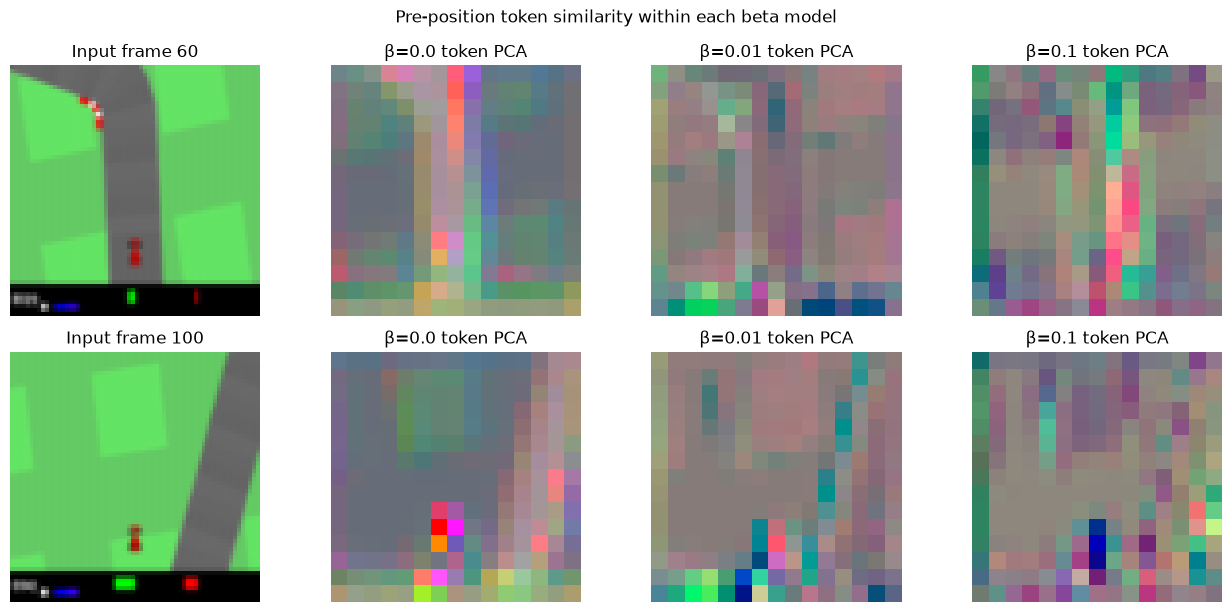

In [4]:
# Each beta uses one PCA fitted to both frames: compare colours within a column, never hue across columns.
def tokenize(model, image):
    model.eval()
    with torch.no_grad():
        features = model.encoder(image)
        _tokens, mu, logvar = model.tokenizer(features)
    return mu[0].cpu(), logvar[0].cpu()

token_pca = {}
for label, model in models.items():
    mu_a, _ = tokenize(model, image_a)
    mu_b, _ = tokenize(model, image_b)
    all_mu = torch.cat([mu_a, mu_b], dim=0)
    centered = all_mu - all_mu.mean(dim=0)
    _u, _s, components = torch.pca_lowrank(centered, q=3)
    values = (centered @ components).numpy()
    scale = np.percentile(np.abs(values), 99) + 1e-8
    token_pca[label] = np.clip((values / scale + 1) / 2, 0, 1)

side = int(np.sqrt(len(next(iter(token_pca.values()))) // 2))
fig, axes = plt.subplots(2, 4, figsize=(13, 6.2))
for row, (index, image) in enumerate([(FRAME_A, image_a), (FRAME_B, image_b)]):
    axes[row, 0].imshow(image[0].detach().cpu().permute(1, 2, 0))
    axes[row, 0].set_title(f'Input frame {index}')
    for col, label in enumerate(CHECKPOINTS, start=1):
        start = row * side * side
        colours = token_pca[label][start:start + side * side].reshape(side, side, 3)
        axes[row, col].imshow(colours, interpolation='nearest')
        axes[row, col].set_title(f'{label} token PCA')
    for ax in axes[row]:
        ax.axis('off')
fig.suptitle('Pre-position token similarity within each beta model')
fig.tight_layout()
token_map_fig = fig
plt.show()

## Stochastic sampling check

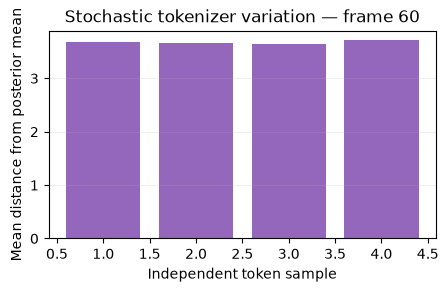

Mean sample distance: 3.671


In [5]:
# Compare four reparameterized token samples with the posterior mean for the same fixed input.
N_SAMPLES = 4
model = models['β=0.1']  # Default stochastic configuration.
mu_a, _ = tokenize(model, image_a)
was_training = model.tokenizer.training
model.tokenizer.train()
sample_distances = []
with torch.no_grad():
    features = model.encoder(image_a)
    for _ in range(N_SAMPLES):
        sampled_tokens, _mu, _logvar = model.tokenizer(features)
        sampled_without_position = sampled_tokens[0] - model.tokenizer.pos_embed_buffer[0]
        sample_distances.append(torch.linalg.vector_norm(sampled_without_position.cpu() - mu_a, dim=-1).mean().item())
model.tokenizer.train(was_training)

fig, ax = plt.subplots(figsize=(5, 2.7))
ax.bar(range(1, N_SAMPLES + 1), sample_distances, color='tab:purple')
ax.set(xlabel='Independent token sample', ylabel='Mean distance from posterior mean',
       title=f'Stochastic tokenizer variation — frame {FRAME_A}')
ax.grid(axis='y', alpha=.2)
plt.show()
print(f'Mean sample distance: {np.mean(sample_distances):.3f}')

## Record an evidence image

In [6]:
# Exploratory visual evidence only; PCA hue is comparable within each beta column, not across models.
EVIDENCE_DIR = ROOT / 'runs/evidence/tokenization'
EVIDENCE_DIR.mkdir(parents=True, exist_ok=True)
output_path = EVIDENCE_DIR / f'{ROLLOUT_PATH.stem}_frames{FRAME_A}_{FRAME_B}.png'
token_map_fig.savefig(output_path, dpi=160, bbox_inches='tight')
print(f'Saved: {output_path.relative_to(ROOT)}')

Saved: runs/evidence/tokenization/2025-08-01T19-26-21_act_frames60_100.png
